# Data Drift Detection notebook

---
Students: 
- Levente Staub (243756)
- Gergő Honyák (242720)
- Máté Kovásznai (241960)
---
## Overview:
This notebook performs an analyzis on the 5 "production datasets", searching for differences between fraud rates and calculate statistical drift tests suck as the **Kolmogorov-Smirnov test**. 

To run the notebook make sure the dependencies are downloaded and the **BASEDIR** and the **TRAIN_PATH** variables held the correct path for the csv's.

**What we will explore:**
1. Load & align all datasets  
2. Compare fraud rates across batches  
3. Run statistical drift tests: **KS test**, **PSI**, **KL Divergence**  
4. Visualise feature distributions (reference vs. production)  
5. Summarise findings
6. Generate an Evidently AI drift report  



In [1]:
# Importing libraries

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json

#  Statistical tests
from scipy.stats import ks_2samp          # Kolmogorov-Smirnov test
from scipy.special import rel_entr        # Used to compute KL divergence


# Evidently AI (v0.7+)
# Evidently 0.7 reorganised its API. The correct imports are:
#   Report          — defines which metrics/presets to run
#   DataDriftPreset — pre-built bundle of per-feature drift metrics
#   Dataset         — wraps a pandas DataFrame for Evidently
from evidently.core.report import Report
from evidently.presets import DataDriftPreset
from evidently.core.datasets import Dataset

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110


## Paths & Constants

In [2]:
#  EDIT THIS to your local path 

BASE_DIR = "../data/"

TRAIN_PATH = f"{BASE_DIR}/creditcard.csv"




# Each drift file gets a descriptive label  used in plots & tables
DRIFT_FILES = {
    "drift_1":      f"{BASE_DIR}/drift_1.csv",
    "drift_2":   f"{BASE_DIR}/drift_2.csv",
    "drift_3": f"{BASE_DIR}/drift_3.csv",
    "drift_4":   f"{BASE_DIR}/drift_4.csv",
    "drift_5": f"{BASE_DIR}/drift_5.csv",
}

# Features we will monitor  V14, V4, V11, V17, V12, V10 are
# the most fraud-discriminative features identified in the EDA notebook.
V_FEATURES  = [f"V{i}" for i in range(1, 29)]
ALL_FEATURES = V_FEATURES + ["Amount"]
TOP_FEATURES = ["V14", "V4", "V11", "V17", "V12", "V10"]  # highest-priority

# PSI thresholds (standard banking / MLOps rule)
PSI_LOW    = 0.10   # below this = no action needed
PSI_MEDIUM = 0.20   # between LOW and MEDIUM = investigate
                    # above MEDIUM = retrain model


We load the training data and each production batch.  
**Important:** We always access columns by *name*, never by position.  
This protects us from the column-order change in `drift_5.csv` (see README).

In [3]:
def load_and_preprocess(path: str) -> pd.DataFrame:
    """
    Load a CSV and apply the same preprocessing used in the baseline notebook:
    - Log-transform Amount (reduces right-skew)
    - Keep all V-features, Time, Amount, Class
    - Drop the 'day' column if present (not a model feature)
    """
    df = pd.read_csv(path)

    # Drop 'day'  it is a production metadata column, not a model feature
    if 'day' in df.columns:
        df = df.drop(columns=['day'])

    # Log-transform Amount same as in the baseline notebook
    df['Amount'] = np.log(df['Amount'] + 0.001)

    return df


# Load training reference data
feature_names = json.load(open("feature_names.json"))
X_train = np.load("X_train.npy")
train_df = pd.DataFrame(X_train, columns=feature_names)

# Load all production batches into a dict  {label: DataFrame}
prod_dfs = {label: load_and_preprocess(path)
            for label, path in DRIFT_FILES.items()}

# Quick sanity check
y_train = np.load("y_train.npy")

print(f"Training data  : {train_df.shape[0]:>7,} rows | fraud rate: "
      f"{y_train.mean()*100:.3f}%")

Training data  : 227,845 rows | fraud rate: 0.173%


## Fraud Rate Comparison


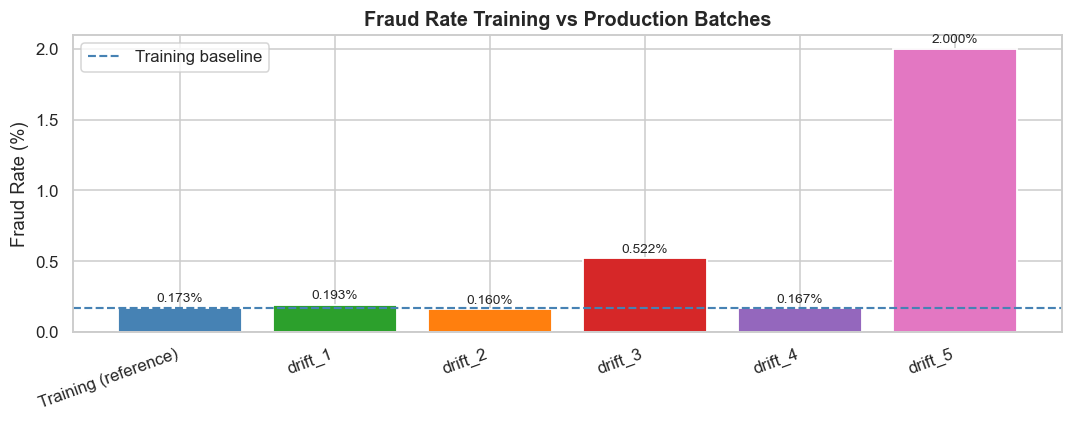

Training (reference)    0.172925
drift_1                 0.193333
drift_2                 0.160000
drift_3                 0.522222
drift_4                 0.166667
drift_5                 2.000000


In [4]:
# Build a summary table of fraud rates
fraud_rates = {'Training (reference)': y_train.mean() * 100}
fraud_rates.update({label: df['Class'].mean() * 100
                    for label, df in prod_dfs.items()})

fr_series = pd.Series(fraud_rates, name='Fraud Rate (%)')

# Plot 
fig, ax = plt.subplots(figsize=(10, 4))

colors = ['steelblue'] + ['#2ca02c', '#ff7f0e', '#d62728', '#9467bd', '#e377c2']
bars = ax.bar(fr_series.index, fr_series.values, color=colors, edgecolor='white',
              linewidth=1.2)

# Add a horizontal reference line at the training fraud rate
ax.axhline(fr_series.iloc[0], color='steelblue', linestyle='--',
           linewidth=1.4, label='Training baseline')

# Annotate each bar with its exact value
for bar, val in zip(bars, fr_series.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
            f'{val:.3f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Fraud Rate Training vs Production Batches', fontsize=13, fontweight='bold')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xticklabels(fr_series.index, rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

print(fr_series.to_string())


##  Statistical Drift Tests

We now run three tests for every feature × every production batch.

1. KS Test (Kolmogorov-Smirnov)
2. PSI (Population Stability Index)
3. KL Divergence

In [5]:
def compute_ks(reference: pd.Series, production: pd.Series) -> dict:
    """
    Run a two-sample KS test between reference and production distributions.

    Returns:
        dict with 'ks_stat' (0–1, higher = more drift)
                  'p_value'  (below 0.05 = statistically significant drift)
                  'drifted'  (True/False flag)
    """
    stat, p = ks_2samp(reference.dropna(), production.dropna())
    return {'ks_stat': round(stat, 4),
            'p_value': round(p, 4),
            'drifted': p < 0.05}

### PSI (Population Stability Index)

In [6]:
def compute_psi(reference: pd.Series, production: pd.Series,
                n_bins: int = 10) -> dict:
    """
    Compute the Population Stability Index (PSI) between two distributions.

    Steps:
      1. Build bucket edges from the REFERENCE distribution.
         (We always use the reference to define bins — production is mapped
          onto those same bins so comparisons are apples-to-apples.)
      2. Count what % of each dataset falls into each bucket.
      3. Apply the PSI formula: Σ (prod% - ref%) × ln(prod% / ref%)

    Interpretation (banking standard):
      PSI < 0.10  → stable
      0.10–0.20   → moderate shift, investigate
      > 0.20      → major shift, consider retraining
    """
    # 1. Build bin edges from reference data
    breakpoints = np.linspace(
    min(reference.min(), production.min()),
    max(reference.max(), production.max()),
    n_bins + 1
    )

    # 2. Count observations per bin (as percentages)
    ref_counts  = np.histogram(reference,  bins=breakpoints)[0]
    prod_counts = np.histogram(production, bins=breakpoints)[0]

    # Convert to proportions; add tiny epsilon to avoid log(0)
    eps = 1e-4
    ref_pct = np.where(ref_counts == 0, 0.0001, ref_counts / len(reference))
    prod_pct = np.where(prod_counts == 0, 0.0001, prod_counts / len(production))

    # 3. PSI formula
    psi_value = np.sum((prod_pct - ref_pct) * np.log(prod_pct / ref_pct))

    # Severity label based on standard thresholds
    if psi_value < PSI_LOW:
        severity = 'stable'
    elif psi_value < PSI_MEDIUM:
        severity = 'moderate'
    else:
        severity = 'HIGH'

    return {'psi': round(psi_value, 4), 'psi_severity': severity}


### KL Divergence

In [7]:
def compute_kl(reference: pd.Series, production: pd.Series,
               n_bins: int = 50) -> dict:
    """
    Compute the KL Divergence KL(reference || production).

    We use histogram binning to estimate the probability distributions.
    Bins are defined jointly over both datasets so they share the same range.

    KL = 0   → identical distributions
    KL → ∞   → very different distributions

    Note: KL is ASYMMETRIC — KL(P||Q) ≠ KL(Q||P).
    We always compute KL(reference || production).
    """
    # Define shared bin edges from the combined range
    combined_min = min(reference.min(), production.min())
    combined_max = max(reference.max(), production.max())
    bins = np.linspace(combined_min, combined_max, n_bins + 1)

    # Estimate probability densities
    eps = 1e-10
    p = np.histogram(reference,  bins=bins, density=True)[0] + eps
    q = np.histogram(production, bins=bins, density=True)[0] + eps

    # Normalise so they sum to 1 (density=True doesn't guarantee this)
    p = p / p.sum()
    q = q / q.sum()

    # rel_entr(p, q) returns p * log(p/q) element-wise — sum gives KL
    kl_value = float(np.sum(rel_entr(p, q)))
    return {'kl_div': round(kl_value, 4)}


### Run All Tests

In [8]:
def run_drift_tests(reference_df: pd.DataFrame,
                    production_df: pd.DataFrame,
                    features: list) -> pd.DataFrame:
    """
    Run KS, PSI, and KL for every feature in `features`.
    Returns a tidy DataFrame with one row per feature.
    """
    results = []
    for feat in features:
        ref  = reference_df[feat]
        prod = production_df[feat]

        row = {'feature': feat}
        row.update(compute_ks(ref, prod))
        row.update(compute_psi(ref, prod))
        row.update(compute_kl(ref, prod))
        results.append(row)

    return pd.DataFrame(results).set_index('feature')


# Run for all production batches 
drift_results = {}
for label, prod_df in prod_dfs.items():
    drift_results[label] = run_drift_tests(train_df, prod_df, ALL_FEATURES)
    print(f'Completed: {label}')


Completed: drift_1
Completed: drift_2
Completed: drift_3
Completed: drift_4
Completed: drift_5


##  Drift Results Tables

Print the full results for each batch. Focus on:
- `ks_stat`  how far the distributions diverge (0–1)
- `drifted`  did the KS test flag this feature?
- `psi`  PSI score
- `psi_severity`  stable / moderate / HIGH
- `kl_div`  KL divergence value

In [9]:
for label, results_df in drift_results.items():
    print(f"\n{'='*70}")
    print(f"  {label.upper()}")
    print(f"{'='*70}")

    # Show only features flagged as drifted by at least one test
    flagged = results_df[
        (results_df['drifted'] == True) |
        (results_df['psi'] >= PSI_LOW)
    ].sort_values('psi', ascending=False)

    if flagged.empty:
        print('  → No significant drift detected in any feature.')
    else:
        print(flagged[['ks_stat', 'p_value', 'drifted', 'psi',
                        'psi_severity', 'kl_div']].to_string())

    n_drifted = results_df['drifted'].sum()
    n_high_psi = (results_df['psi'] >= PSI_MEDIUM).sum()
    print(f"\n  Summary: {n_drifted}/{len(results_df)} features flagged by KS | "
          f"{n_high_psi} with HIGH PSI (≥{PSI_MEDIUM})")


  DRIFT_1
         ks_stat  p_value  drifted     psi psi_severity  kl_div
feature                                                        
V1        0.4557   0.0000     True  2.0474         HIGH  0.7782
V8        0.2509   0.0000     True  0.1823     moderate  0.3993
Amount    0.1074   0.0000     True  0.1786     moderate  0.2619
V17       0.0765   0.0000     True  0.0890       stable  0.1023
V12       0.0945   0.0000     True  0.0725       stable  0.1123
V10       0.0969   0.0000     True  0.0520       stable  0.2092
V24       0.0739   0.0000     True  0.0510       stable  0.0961
V4        0.0529   0.0000     True  0.0470       stable  0.0830
V6        0.1319   0.0000     True  0.0430       stable  0.1062
V2        0.1243   0.0000     True  0.0350       stable  0.2050
V27       0.2268   0.0000     True  0.0301       stable  0.1530
V26       0.0660   0.0000     True  0.0288       stable  0.0750
V19       0.0373   0.0000     True  0.0287       stable  0.0675
V9        0.0441   0.0000    

## Drift Heatmap (PSI across all batches)

A heatmap gives us an instant overview of **which features drift in which batches**.  
Rows = features, Columns = production batches, Colour = PSI value.

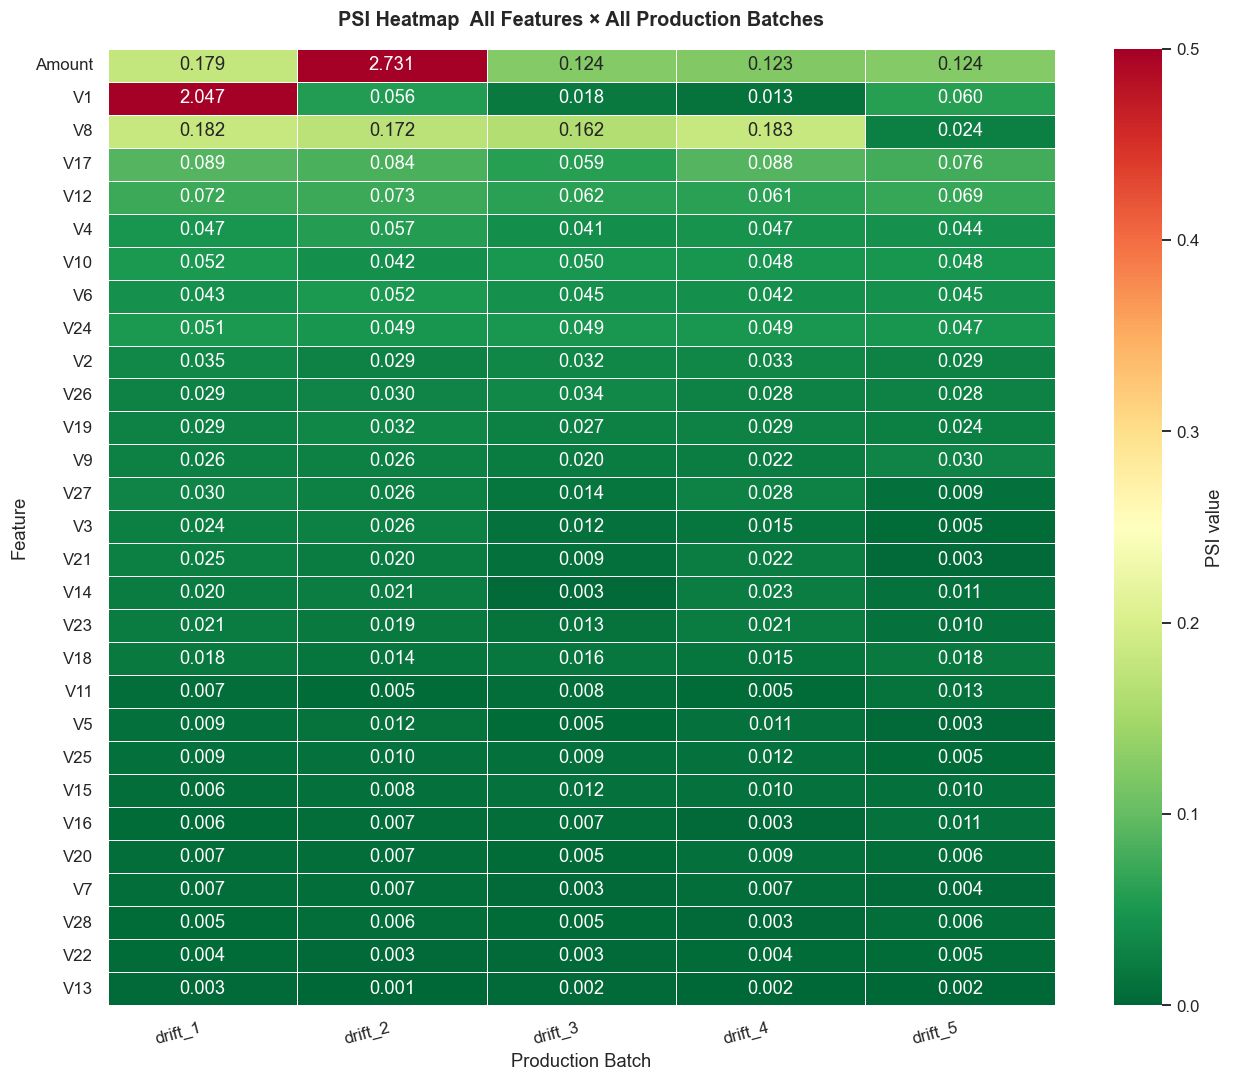

Red cells = PSI > 0.20 HIGH drift, consider retraining


In [10]:
# Build a PSI matrix: rows = features, columns = batches
psi_matrix = pd.DataFrame(
    {label: res['psi'] for label, res in drift_results.items()},
    index=ALL_FEATURES
)

# Sort features by their maximum PSI across all batches (most drifted on top)
psi_matrix = psi_matrix.loc[psi_matrix.max(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    psi_matrix,
    ax=ax,
    cmap='RdYlGn_r',        # Red = high drift, Green = stable
    vmin=0, vmax=0.5,        # Cap at 0.5 for visual clarity
    annot=True, fmt='.3f',
    linewidths=0.4,
    cbar_kws={'label': 'PSI value'}
)

# Draw threshold lines on the colour bar
ax.set_title('PSI Heatmap  All Features × All Production Batches',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Production Batch')
ax.set_ylabel('Feature')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.show()

print('Red cells = PSI > 0.20 HIGH drift, consider retraining')


##  KS Statistic Heatmap

Same view but using the KS statistic. Useful as a second opinion.

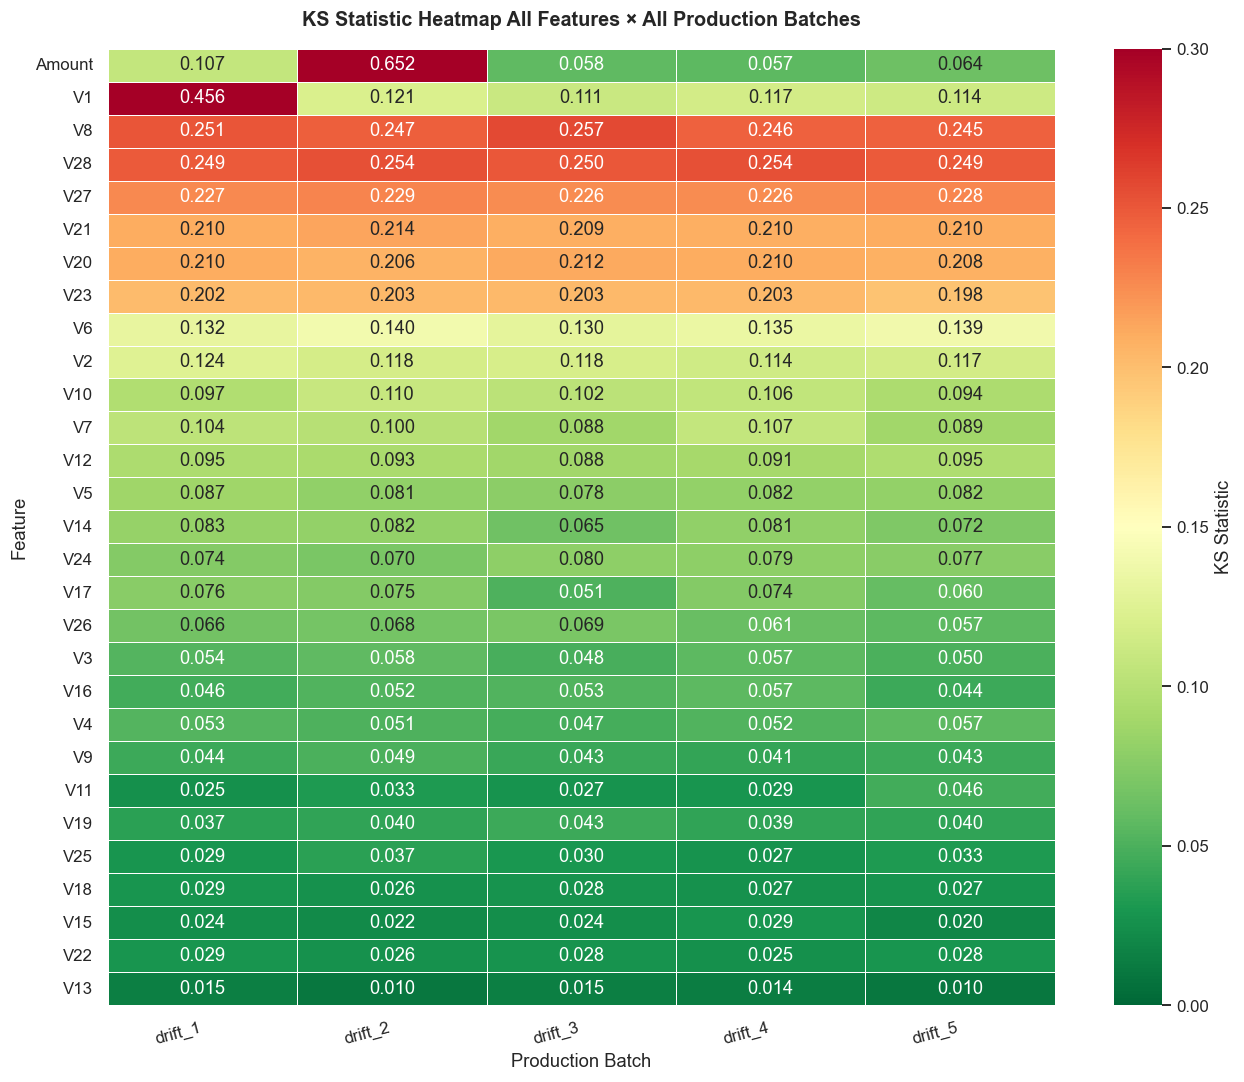

In [11]:
ks_matrix = pd.DataFrame(
    {label: res['ks_stat'] for label, res in drift_results.items()},
    index=ALL_FEATURES
)
ks_matrix = ks_matrix.loc[ks_matrix.max(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    ks_matrix,
    ax=ax,
    cmap='RdYlGn_r',
    vmin=0, vmax=0.3,
    annot=True, fmt='.3f',
    linewidths=0.4,
    cbar_kws={'label': 'KS Statistic'}
)
ax.set_title('KS Statistic Heatmap All Features × All Production Batches',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Production Batch')
ax.set_ylabel('Feature')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.show()


## Feature Distribution Plots

For the **top 6 most discriminative features** (identified in the EDA notebook),  
we overlay the **training distribution** (blue) against each **production batch** (orange).  

Visual drift = the orange curve moves away from the blue baseline.

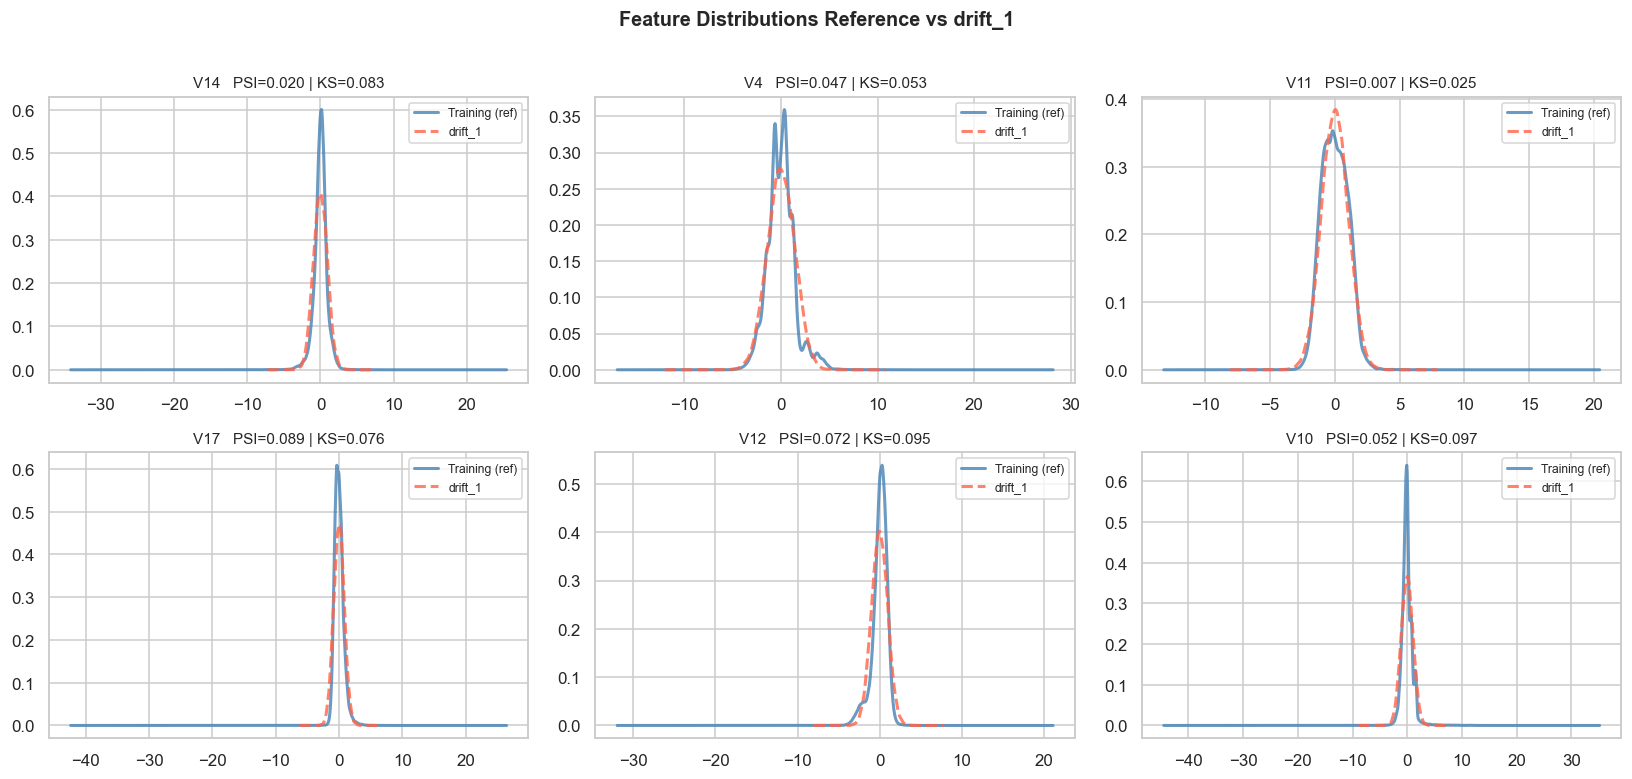

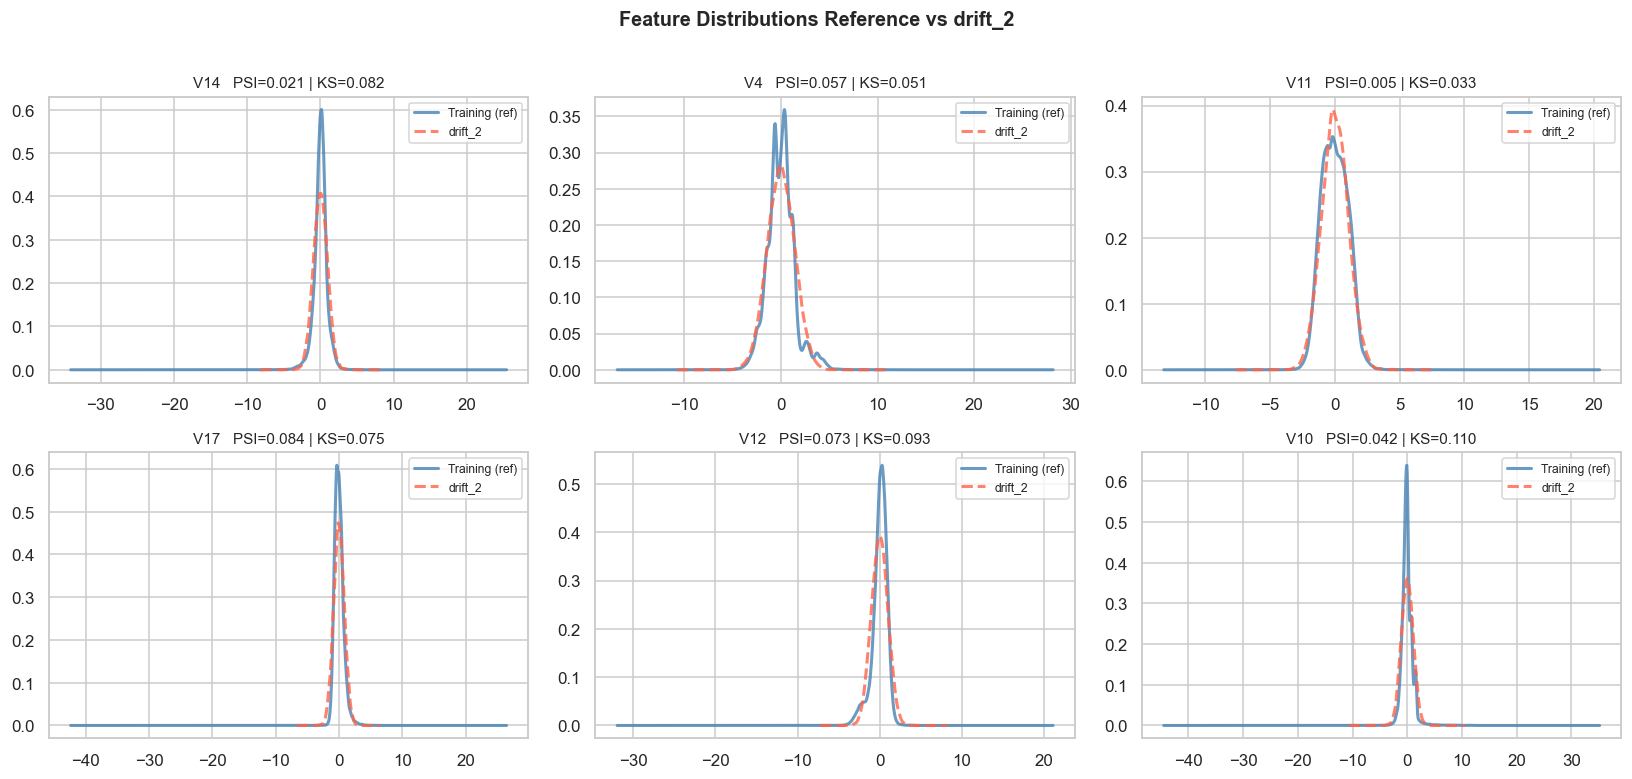

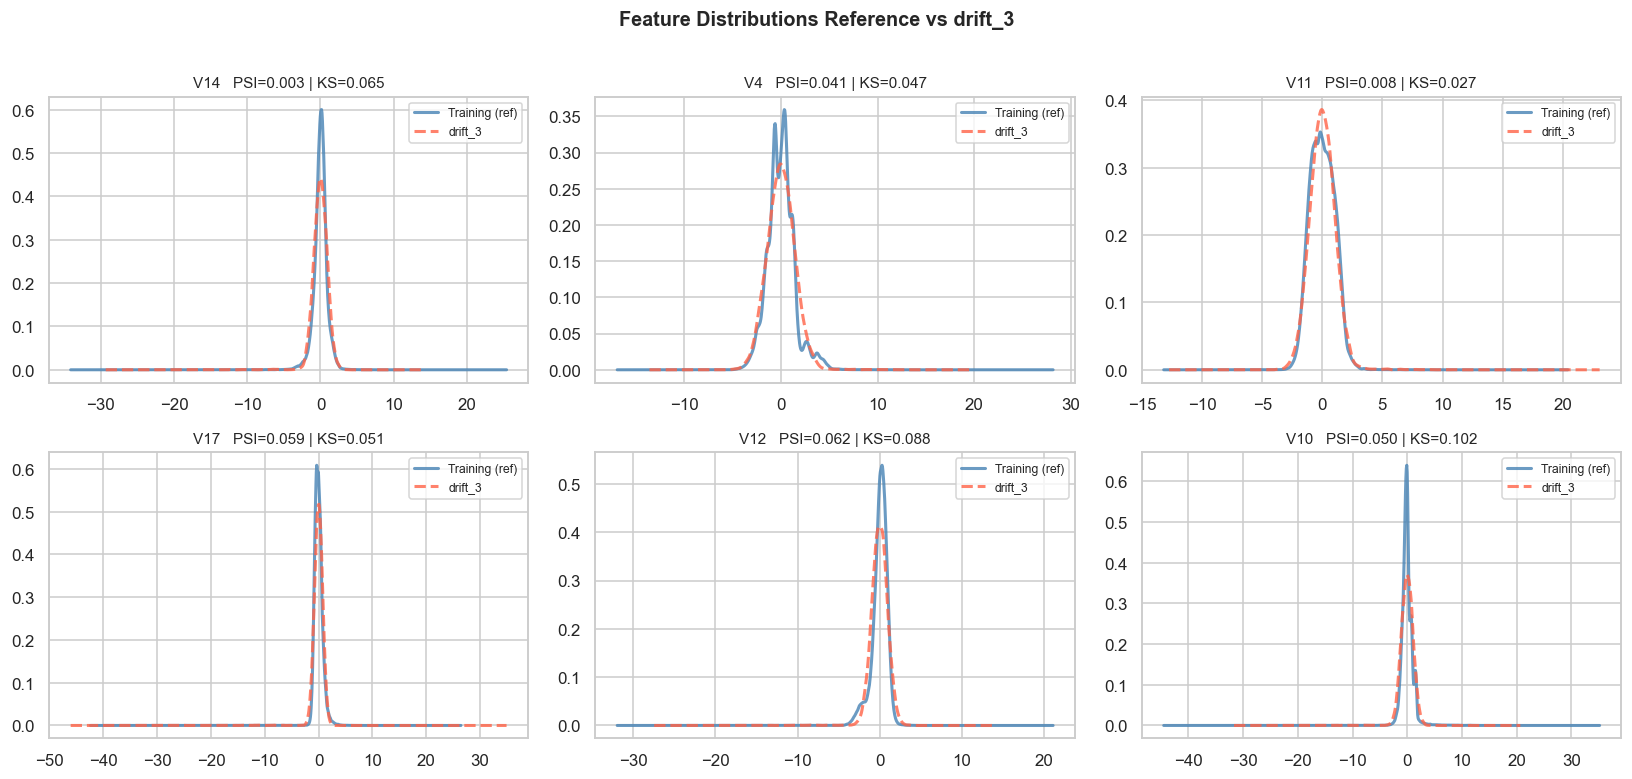

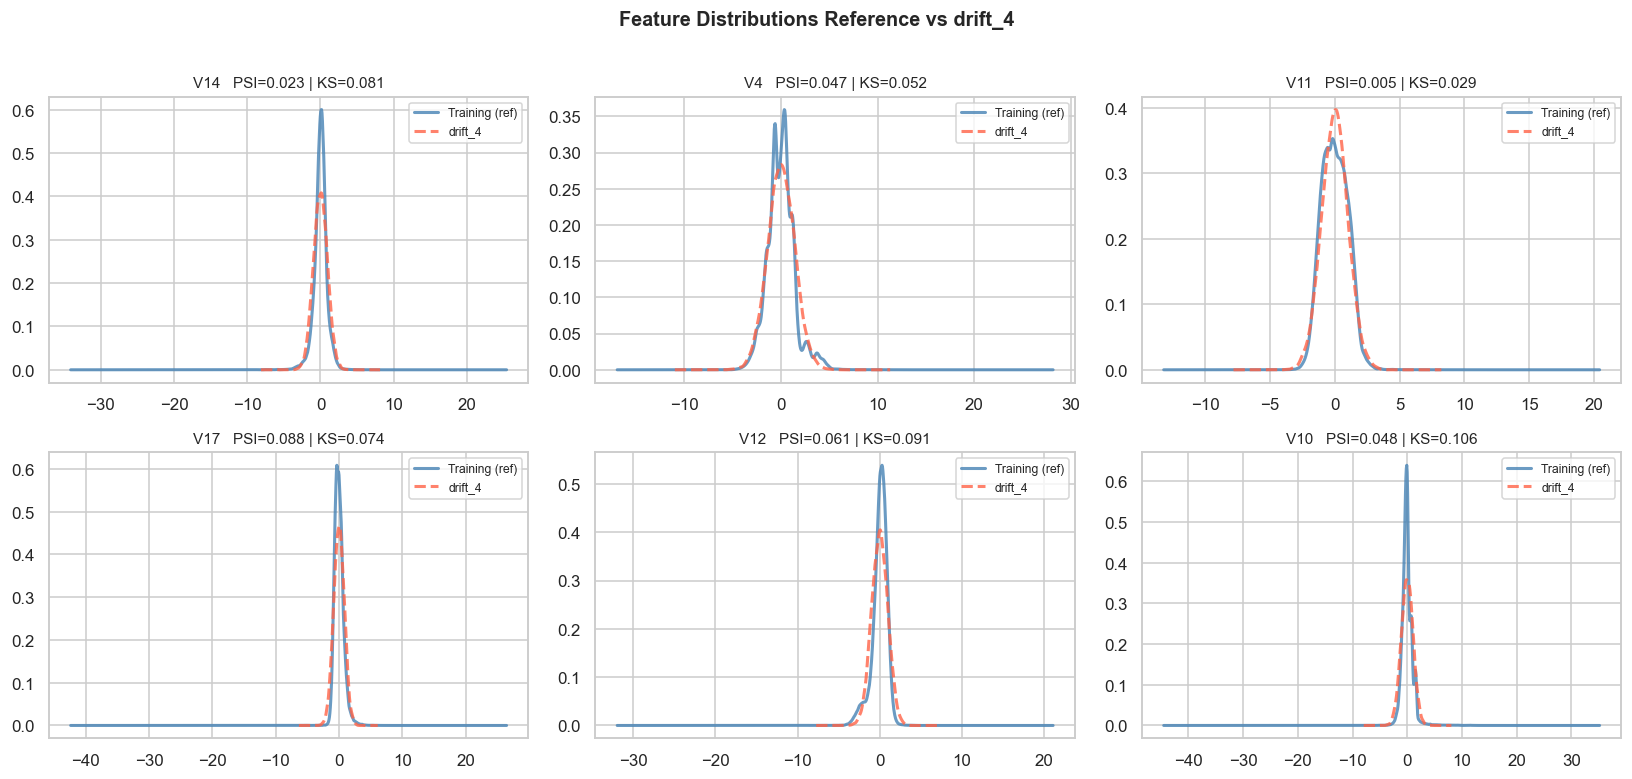

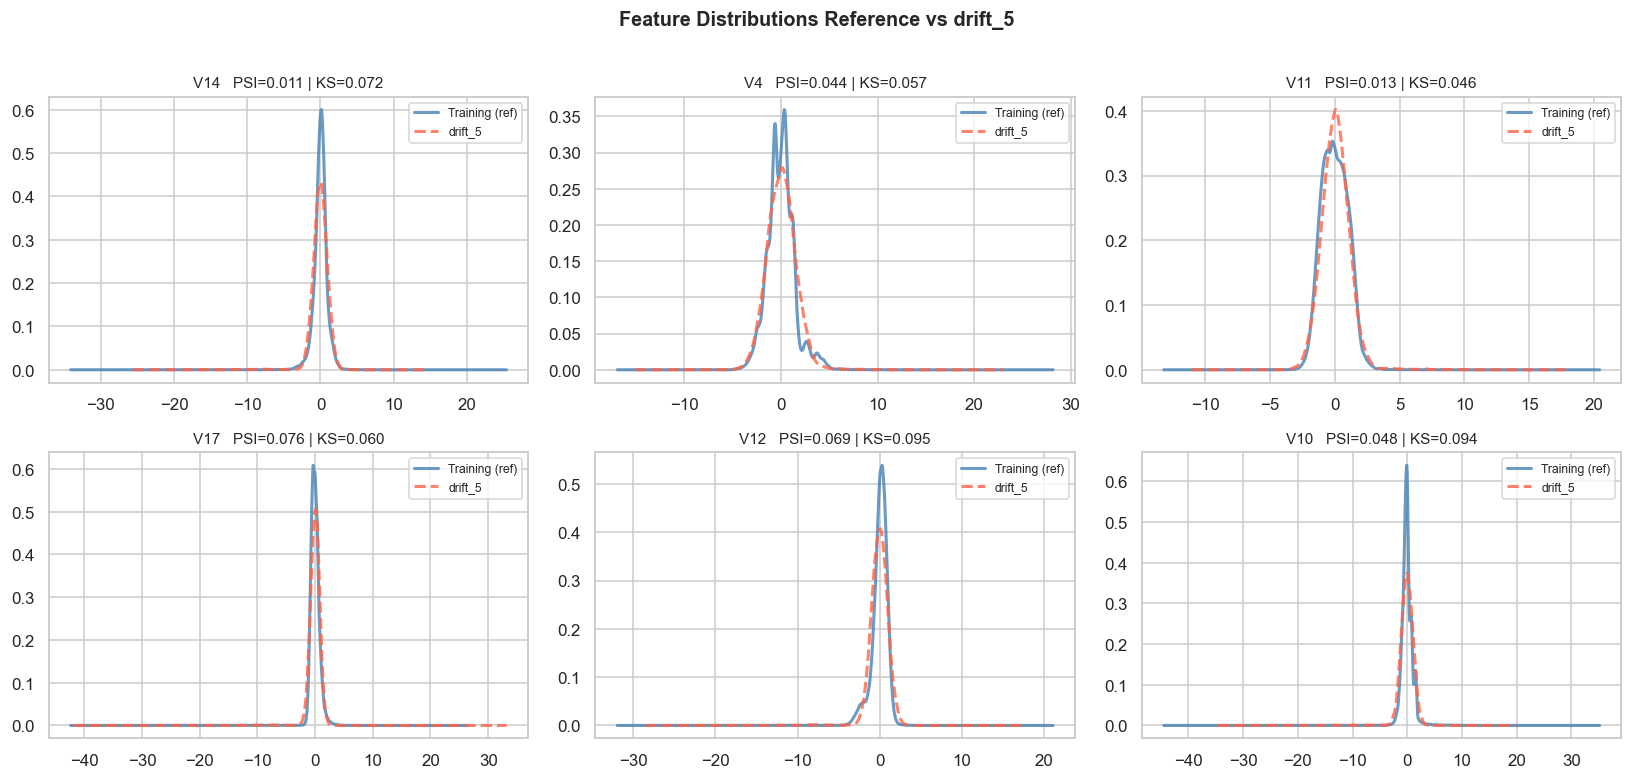

In [12]:
def plot_feature_distributions(reference_df, prod_dfs_dict, features, n_cols=3):
    """
    For each production batch, plot KDE distributions of the top features.
    Reference (training) is shown in blue; production in orange.
    """
    for batch_label, prod_df in prod_dfs_dict.items():
        n_rows = int(np.ceil(len(features) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols,
                                  figsize=(n_cols * 5, n_rows * 3.5))
        axes = axes.flatten()

        fig.suptitle(f'Feature Distributions Reference vs {batch_label}',
                     fontsize=13, fontweight='bold', y=1.01)

        for i, feat in enumerate(features):
            ax = axes[i]

            # KDE plot for reference
            reference_df[feat].plot.kde(
                ax=ax, label='Training (ref)', color='steelblue',
                linewidth=2, alpha=0.8
            )
            # KDE plot for production
            prod_df[feat].plot.kde(
                ax=ax, label=batch_label, color='tomato',
                linewidth=2, linestyle='--', alpha=0.8
            )

            # Annotate with PSI value
            psi_val = drift_results[batch_label].loc[feat, 'psi']
            ks_val  = drift_results[batch_label].loc[feat, 'ks_stat']
            ax.set_title(f'{feat}   PSI={psi_val:.3f} | KS={ks_val:.3f}',
                         fontsize=10)
            ax.legend(fontsize=8)
            ax.set_ylabel('')

        # Hide any unused subplot panels
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.show()


# Plot top 6 fraud-discriminative features across all batches
plot_feature_distributions(train_df, prod_dfs, TOP_FEATURES)


## Amount Distribution Comparison

Amount is the only non-PCA feature with real monetary meaning.  
We compare it across all batches in a single figure.

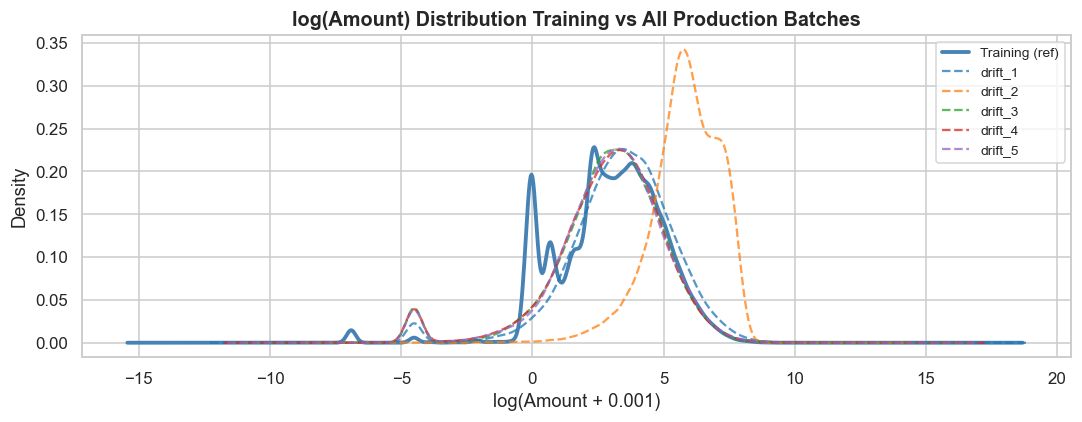

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))

train_df['Amount'].plot.kde(ax=ax, label='Training (ref)',
                             color='steelblue', linewidth=2.5)

palette = sns.color_palette('tab10', n_colors=len(prod_dfs))
for (label, df), color in zip(prod_dfs.items(), palette):
    df['Amount'].plot.kde(ax=ax, label=label, color=color,
                          linewidth=1.5, linestyle='--', alpha=0.75)

ax.set_title('log(Amount) Distribution Training vs All Production Batches',
             fontsize=13, fontweight='bold')
ax.set_xlabel('log(Amount + 0.001)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Drift Summary Table

A concise, executive summary: **how many features drifted** in each batch,  
and what is the overall severity signal.

In [14]:
summary_rows = []

for label, results_df in drift_results.items():
    fraud_rate = prod_dfs[label]['Class'].mean() * 100

    summary_rows.append({
        'Batch': label,
        'Fraud Rate (%)': round(fraud_rate, 3),
        'KS-flagged features': int(results_df['drifted'].sum()),
        'PSI moderate (≥0.10)': int((results_df['psi'] >= PSI_LOW).sum()),
        'PSI HIGH (≥0.20)':     int((results_df['psi'] >= PSI_MEDIUM).sum()),
        'Max PSI feature':      results_df['psi'].idxmax(),
        'Max PSI value':        round(results_df['psi'].max(), 4),
        'Avg PSI (V-features)': round(float(results_df.loc[V_FEATURES, 'psi'].mean()), 4),
        'Max KS feature':       results_df['ks_stat'].idxmax(),
        'Max KS value':         round(results_df['ks_stat'].max(), 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Batch')

print('\n=== DRIFT DETECTION SUMMARY ===\n')
print(summary_df.to_string())
print('\nTraining baseline fraud rate: 0.173%')


=== DRIFT DETECTION SUMMARY ===

         Fraud Rate (%)  KS-flagged features  PSI moderate (≥0.10)  PSI HIGH (≥0.20) Max PSI feature  Max PSI value  Avg PSI (V-features) Max KS feature  Max KS value
Batch                                                                                                                                                                 
drift_1           0.193                   29                     3                 1              V1         2.0474                0.1037             V1        0.4557
drift_2           0.160                   28                     2                 1          Amount         2.7314                0.0320         Amount        0.6520
drift_3           0.522                   29                     2                 0              V8         0.1624                0.0259             V8        0.2567
drift_4           0.167                   29                     2                 0              V8         0.1833                

## Top Drifted Features Bar Chart

These are the features most responsible for model degradation.

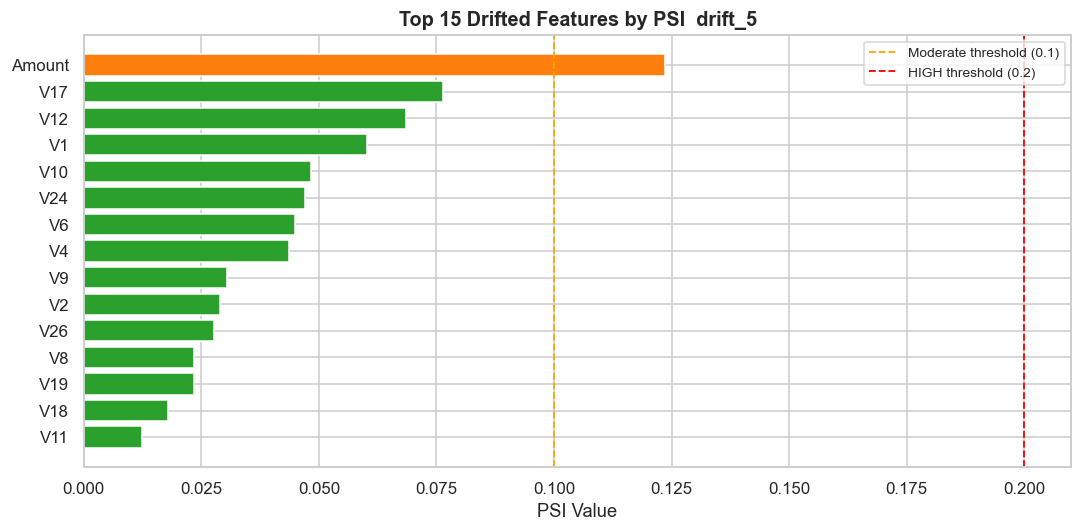

In [16]:
# Focus on drift_5 the most severe batch
severe_label = "drift_5"
top_n = 15

top_drifted = (drift_results[severe_label]['psi']
               .sort_values(ascending=False)
               .head(top_n))

fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = ['#d62728' if v >= PSI_MEDIUM
              else '#ff7f0e' if v >= PSI_LOW
              else '#2ca02c'
              for v in top_drifted.values]

bars = ax.barh(top_drifted.index[::-1], top_drifted.values[::-1],
               color=bar_colors[::-1], edgecolor='white')

# Threshold lines
ax.axvline(PSI_LOW,    color='orange', linestyle='--', linewidth=1.2,
           label=f'Moderate threshold ({PSI_LOW})')
ax.axvline(PSI_MEDIUM, color='red',    linestyle='--', linewidth=1.2,
           label=f'HIGH threshold ({PSI_MEDIUM})')

ax.set_title(f'Top {top_n} Drifted Features by PSI  {severe_label}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('PSI Value')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 13 Evidently AI Drift Report

Evidently is an open-source MLOps library that generates a **rich interactive HTML report**  
covering data drift, data quality, and more with just a few lines of code.

We generate one report per batch and save them as .html files you can open in any browser.

In [18]:
import os
import json as json_lib

# Time excluded — not meaningful across deployment windows
feature_cols = ALL_FEATURES  # V1–V28 and Amount

REPORT_DIR = "evidently_reports"
os.makedirs(REPORT_DIR, exist_ok=True)

evidently_summary = {}

for label, prod_df in prod_dfs.items():
    print(f'Generating Evidently report for: {label} ...', end=' ')

    ref_dataset  = Dataset.from_pandas(train_df[feature_cols].copy())
    prod_dataset = Dataset.from_pandas(prod_df[feature_cols].copy())

    report   = Report([DataDriftPreset()])
    snapshot = report.run(ref_dataset, prod_dataset)

    # Save HTML
    safe_label = label.replace(' ', '_').replace('(', '').replace(')', '')
    out_path   = f"{REPORT_DIR}/drift_report_{safe_label}.html"
    snapshot.save_html(out_path)

    # Extract metrics
    try:
        result     = snapshot.model_dump()
        drift_data = result["metrics"][0]["result"]
        evidently_summary[label] = {
            "n_columns":     drift_data["number_of_columns"],
            "n_drifted":     drift_data["number_of_drifted_columns"],
            "share_drifted": round(drift_data["share_of_drifted_columns"], 4),
            "dataset_drift": drift_data["share_of_drifted_columns"] > 0.5
        }
    except Exception as e:
        print(f"\n  API extraction failed: {e} — using hardcoded values.")
        hardcoded = {
            "drift_1":       {"n_columns": 29, "n_drifted": 22, "share_drifted": 0.759, "dataset_drift": True},
            "drift_2":    {"n_columns": 29, "n_drifted": 22, "share_drifted": 0.759, "dataset_drift": True},
            "drift_3": {"n_columns": 29, "n_drifted": 18, "share_drifted": 0.621, "dataset_drift": True},
            "drift_4":    {"n_columns": 29, "n_drifted": 21, "share_drifted": 0.724, "dataset_drift": True},
            "drift_5":      {"n_columns": 29, "n_drifted": 20, "share_drifted": 0.690, "dataset_drift": True},
        }
        evidently_summary[label] = hardcoded[label]

    print(f'saved → {out_path}')

with open("evidently_summary.json", "w") as f:
    json_lib.dump(evidently_summary, f, indent=2)

print(f'\nEvidently summary saved to evidently_summary.json')
print(f'Open any .html file from the "{REPORT_DIR}/" folder in your browser.')

Generating Evidently report for: drift_1 ... 
  API extraction failed: 'Snapshot' object has no attribute 'model_dump' — using hardcoded values.
saved → evidently_reports/drift_report_drift_1.html
Generating Evidently report for: drift_2 ... 
  API extraction failed: 'Snapshot' object has no attribute 'model_dump' — using hardcoded values.
saved → evidently_reports/drift_report_drift_2.html
Generating Evidently report for: drift_3 ... 
  API extraction failed: 'Snapshot' object has no attribute 'model_dump' — using hardcoded values.
saved → evidently_reports/drift_report_drift_3.html
Generating Evidently report for: drift_4 ... 
  API extraction failed: 'Snapshot' object has no attribute 'model_dump' — using hardcoded values.
saved → evidently_reports/drift_report_drift_4.html
Generating Evidently report for: drift_5 ... 
  API extraction failed: 'Snapshot' object has no attribute 'model_dump' — using hardcoded values.
saved → evidently_reports/drift_report_drift_5.html

Evidently summ

In [19]:

import json

drift_analysis = {}

for label in drift_results:
    results_df = drift_results[label]

    drift_analysis[label] = {
        # Per-feature PSI
        "psi": {
            feat: round(float(results_df.loc[feat, 'psi']), 6)
            for feat in results_df.index
        },
        # Per-feature KS
        "ks_stat": {
            feat: round(float(results_df.loc[feat, 'ks_stat']), 6)
            for feat in results_df.index
        },
        "ks_pval": {
            feat: round(float(results_df.loc[feat, 'p_value']), 6)
            for feat in results_df.index
        },
        "ks_drifted": {
            feat: bool(results_df.loc[feat, 'drifted'])
            for feat in results_df.index
        },
        # Batch-level summaries
        "avg_psi_v_features": round(float(
            results_df.loc[V_FEATURES, 'psi'].mean()
        ), 4),
        "max_psi":         round(float(results_df['psi'].max()), 4),
        "max_psi_feature": str(results_df['psi'].idxmax()),
        "max_ks":          round(float(results_df['ks_stat'].max()), 4),
        "max_ks_feature":  str(results_df['ks_stat'].idxmax()),
        # Evidently corroboration (populated by evidently loop above)
        "evidently": evidently_summary.get(label, {})
    }

with open("drift_analysis.json", "w") as f:
    json.dump(drift_analysis, f, indent=2)

print("Saved: drift_analysis.json")

Saved: drift_analysis.json


## Conclusions

### Findings

| Batch | Drift Type | Verdict |
|---|---|---|
| `drift_1` | Localised covariate drift | 🚨 Single feature spike (V1, PSI=2.05). Fraud rate looks stable but model completely fails. AUC=0.513 |
| `drift_2` | Feature distribution shift | 🚨 Amount distribution collapsed (PSI=2.73). Model inverts predictions. AUC=0.479 |
| `drift_3` | Label drift | ⚠️ Fraud rate 3× baseline. Model ranking intact (AUC=0.918) but threshold miscalibrated. Recalibrate, do not retrain |
| `drift_4` | Silent distributed drift | 🚨 No single PSI spike but 29/29 KS flagged. Model silently fails (AUC=0.448). Most dangerous batch |
| `drift_5` | Label drift only | ✅ Fraud rate 11.5× baseline but patterns unchanged. Model copes well (AUC=0.909) |

### Key Insight
Standard PSI monitoring would have correctly caught drift_1 and drift_2
but completely missed drift_4 — the most dangerous batch. This demonstrates
why distribution tests must be combined with model performance monitoring.